In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import (
    RandomForestClassifier, 
    ExtraTreesClassifier, 
    HistGradientBoostingClassifier, 
    VotingClassifier
)
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

train_data = pd.read_csv('../data/processed/train.csv')
val_data = pd.read_csv('../data/processed/val.csv')
test_data = pd.read_csv('../data/processed/test.csv')

X_train = train_data.drop('LEAVE', axis=1)
y_train = train_data['LEAVE']

X_val = val_data.drop('LEAVE', axis=1)
y_val = val_data['LEAVE']

X_test = test_data.drop('LEAVE', axis=1)
y_test = test_data['LEAVE']

print(f"Размер X_train: {X_train.shape}")

Размер X_train: (14000, 23)


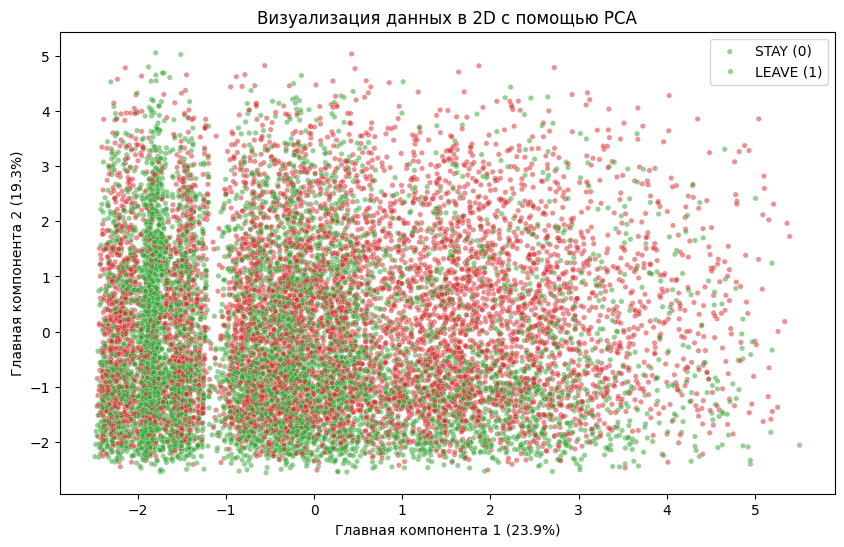

In [3]:
# Инициализируем PCA на 2 компоненты
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_train)

pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['Target'] = y_train.values

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='Target', 
    palette=['#2ca02c', '#d62728'], 
    data=pca_df, 
    alpha=0.5, s=15
)
plt.title('Визуализация данных в 2D с помощью PCA')
plt.xlabel(f"Главная компонента 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Главная компонента 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(['STAY (0)', 'LEAVE (1)'])
plt.show()

In [4]:
# Создаем пустой список для таблицы результатов
experiments_log = []

def run_experiment(model_name, model, param_grid, X_tr, y_tr, X_v, y_v):
    print(f"Запуск: {model_name}...")
    
    # GridSearch для перебора гиперпараметров (оптимизируем по ROC-AUC)
    grid = GridSearchCV(model, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_tr, y_tr)
    
    # Достаем лучшую модель
    best_model = grid.best_estimator_
    print(f"Лучшие параметры: {grid.best_params_}")
    
    # Делаем предсказания на Валидации
    y_pred = best_model.predict(X_v)
    y_pred_proba = best_model.predict_proba(X_v)[:, 1]
    
    # Считаем метрики
    auc = roc_auc_score(y_v, y_pred_proba)
    f1 = f1_score(y_v, y_pred)
    acc = accuracy_score(y_v, y_pred)
    
    # Записываем в лог
    experiments_log.append({
        'Model': model_name,
        'Val_ROC_AUC': round(auc, 4),
        'Val_F1': round(f1, 4),
        'Val_Accuracy': round(acc, 4),
        'Best_Params': str(grid.best_params_)
    })
    
    return best_model

In [5]:
# 1. Random Forest
rf_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5]
}
best_rf = run_experiment("Random Forest", RandomForestClassifier(random_state=42), rf_grid, X_train, y_train, X_val, y_val)

# 2. Extra Trees
et_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
best_et = run_experiment("Extra Trees", ExtraTreesClassifier(random_state=42), et_grid, X_train, y_train, X_val, y_val)

# 3. HistGradientBoosting
hgb_grid = {
    'max_iter': [100, 200],
    'max_depth': [3, 5, None],
    'learning_rate': [0.05, 0.1]
}
best_hgb = run_experiment("HistGradientBoosting", HistGradientBoostingClassifier(random_state=42), hgb_grid, X_train, y_train, X_val, y_val)

# 4. CatBoost
cb_grid = {
    'iterations': [100, 200],
    'depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}
best_cb = run_experiment("CatBoost", CatBoostClassifier(random_state=42, verbose=0), cb_grid, X_train, y_train, X_val, y_val)

# 5. XGBoost
xgb_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}
best_xgb = run_experiment("XGBoost", XGBClassifier(random_state=42, eval_metric='logloss'), xgb_grid, X_train, y_train, X_val, y_val)

# 6. LightGBM
lgb_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, -1],
    'learning_rate': [0.01, 0.05, 0.1]
}
best_lgb = run_experiment("LightGBM", LGBMClassifier(random_state=42, verbose=-1), lgb_grid, X_train, y_train, X_val, y_val)

Запуск: Random Forest...
Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
Запуск: Extra Trees...
Лучшие параметры: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Запуск: HistGradientBoosting...
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': None, 'max_iter': 100}
Запуск: CatBoost...
Лучшие параметры: {'depth': 4, 'iterations': 200, 'learning_rate': 0.05}
Запуск: XGBoost...
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
Запуск: LightGBM...
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 300}


In [6]:
print("\nСоздание финального ансамбля (Voting Classifier)...")

# Объединяем Большую Тройку бустингов
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('lgb', best_lgb),
        ('cb', best_cb)
    ],
    voting='soft' # Усредняем вероятности
)

voting_clf.fit(X_train, y_train)

# Оцениваем ансамбль
y_pred_vote = voting_clf.predict(X_val)
y_pred_proba_vote = voting_clf.predict_proba(X_val)[:, 1]

# ВАЖНО: Если вы запускаете эту ячейку повторно в том же ноутбуке, 
# проверьте, чтобы 'experiments_log' не начал дублировать записи.
# Если что, можно просто перезапустить ядро и прогнать все ячейки с нуля.
experiments_log.append({
    'Model': 'Ensemble (XGB + LGBM + CB)',
    'Val_ROC_AUC': round(roc_auc_score(y_val, y_pred_proba_vote), 4),
    'Val_F1': round(f1_score(y_val, y_pred_vote), 4),
    'Val_Accuracy': round(accuracy_score(y_val, y_pred_vote), 4),
    'Best_Params': 'Soft Voting'
})
print("Ансамбль обучен!")



Создание финального ансамбля (Voting Classifier)...
Ансамбль обучен!


In [7]:
# Превращаем лог в таблицу и сортируем по главной метрике
results_df = pd.DataFrame(experiments_log).sort_values(by='Val_ROC_AUC', ascending=False).reset_index(drop=True)

print("\n--- ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ (на Validation) ---")
display(results_df)


--- ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ (на Validation) ---


,Model,Val_ROC_AUC,Val_F1,Val_Accuracy,Best_Params
0,HistGradientBoosting,0.7702,0.7141,0.6957,"{'learning_rate': 0.05, 'max_depth': None, 'ma..."
1,Ensemble (XGB + LGBM + CB),0.7696,0.7124,0.6957,Soft Voting
2,XGBoost,0.7684,0.7118,0.6950,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
3,LightGBM,0.7684,0.7158,0.6953,"{'learning_rate': 0.01, 'max_depth': -1, 'n_es..."
4,CatBoost,0.7681,0.7023,0.6897,"{'depth': 4, 'iterations': 200, 'learning_rate..."
5,Random Forest,0.7659,0.7057,0.6997,"{'max_depth': 10, 'min_samples_leaf': 5, 'n_es..."
6,Extra Trees,0.7496,0.6590,0.6733,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."


In [8]:
# Выбираем лучшую модель из всех, что мы обучили
best_model_name = results_df.iloc[0]['Model']

print(f"\nЛучшая модель: {best_model_name}!")
print("Проводим финальное тестирование на (TEST) выборке...\n")

# Словарик, чтобы вытащить саму модель по ее названию
models_dict = {
    "Random Forest": best_rf,
    "Extra Trees": best_et,
    "HistGradientBoosting": best_hgb,
    "CatBoost": best_cb,
    "Ensemble (Soft Voting)": voting_clf
}

final_model = models_dict[best_model_name]

# Предсказания на тесте
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

print("--- РЕЗУЛЬТАТЫ ФИНАЛЬНОЙ МОДЕЛИ НА TEST ВЫБОРКЕ ---")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"F1-score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")


Лучшая модель: HistGradientBoosting!
Проводим финальное тестирование на (TEST) выборке...

--- РЕЗУЛЬТАТЫ ФИНАЛЬНОЙ МОДЕЛИ НА TEST ВЫБОРКЕ ---
ROC-AUC:   0.7710
F1-score:  0.7101
Accuracy:  0.6930


In [9]:
from sklearn.model_selection import RandomizedSearchCV

print("Запускаем глубокий поиск параметров (Deep Tuning)...\n")

# 1. Глубокий перебор для победителя (HistGB)
hgb_deep_grid = {
    'max_iter': [200, 300, 500],
    'max_depth': [3, 5, 7, None],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_regularization': [0.0, 0.1, 1.0, 5.0],
    'min_samples_leaf': [10, 20, 50]
}

hgb_random = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=hgb_deep_grid,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

hgb_random.fit(X_train, y_train)
best_hgb_deep = hgb_random.best_estimator_

y_val_proba_hgb = best_hgb_deep.predict_proba(X_val)[:, 1]
auc_hgb = roc_auc_score(y_val, y_val_proba_hgb)
print(f"Новый ROC-AUC HistGB (Val): {auc_hgb:.4f}")


# 2. Глубокий перебор для LightGBM
lgb_deep_grid = {
    'n_estimators': [300, 500, 800],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.005, 0.01, 0.05],
    'subsample': [0.6, 0.8, 1.0],         # Выборка строк
    'colsample_bytree': [0.6, 0.8, 1.0],  # Выборка колонок (защита от переобучения)
    'reg_lambda': [0.0, 1.0, 5.0]         # L2 регуляризация
}

lgb_random = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgb_deep_grid,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

lgb_random.fit(X_train, y_train)
best_lgb_deep = lgb_random.best_estimator_

y_val_proba_lgb = best_lgb_deep.predict_proba(X_val)[:, 1]
auc_lgb = roc_auc_score(y_val, y_val_proba_lgb)
print(f"Новый ROC-AUC LightGBM (Val): {auc_lgb:.4f}")

# Выбираем АБСОЛЮТНОГО победителя для финального теста
if auc_hgb >= auc_lgb:
    final_best_model = best_hgb_deep
    final_val_proba = y_val_proba_hgb
    print("\nПобедил: HistGradientBoosting!")
else:
    final_best_model = best_lgb_deep
    final_val_proba = y_val_proba_lgb
    print("\nПобедил: LightGBM!")

Запускаем глубокий поиск параметров (Deep Tuning)...

Новый ROC-AUC HistGB (Val): 0.7709
Новый ROC-AUC LightGBM (Val): 0.7655

Победил: HistGradientBoosting!


In [10]:
from sklearn.metrics import precision_recall_curve

print("\n--- ОПТИМИЗАЦИЯ БИЗНЕС-МЕТРИКИ (ПОРОГА) ---")

# Получаем точность и полноту для всех возможных порогов 
# (используем вероятности победившей модели из прошлой ячейки: final_val_proba)
precisions, recalls, thresholds = precision_recall_curve(y_val, final_val_proba)

# Считаем F1-score для каждого порога
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-9)

# Находим идеальный порог
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Идеальный порог отсечения вероятности: {best_threshold:.4f}")
print(f"Максимальный F1-score на валидации:   {best_f1:.4f}")


print("\n--- ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА TEST ВЫБОРКЕ ---")

# Предсказываем вероятности на отложенной ТЕСТОВОЙ выборке
final_test_proba = final_best_model.predict_proba(X_test)[:, 1]

# Применяем найденный идеальный порог
final_test_pred_custom = (final_test_proba >= best_threshold).astype(int)

# Выводим финальные боевые метрики
print(f"Test ROC-AUC:  {roc_auc_score(y_test, final_test_proba):.4f}")
print(f"Test F1-score: {f1_score(y_test, final_test_pred_custom):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, final_test_pred_custom):.4f}")


--- ОПТИМИЗАЦИЯ БИЗНЕС-МЕТРИКИ (ПОРОГА) ---
Идеальный порог отсечения вероятности: 0.4059
Максимальный F1-score на валидации:   0.7438

--- ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА TEST ВЫБОРКЕ ---
Test ROC-AUC:  0.7709
Test F1-score: 0.7417
Test Accuracy: 0.6950


In [11]:
import joblib

# Сохраняем нашу финальную модель (HistGradientBoosting) в файл
joblib.dump(final_best_model, '../models/best_model.pkl')

# Также нам нужно сохранить порог отсечения, который мы нашли (0.4059)
# Сохраним его просто как текст, чтобы потом вписать в API
print(f"Модель сохранена! Наш идеальный порог: {best_threshold:.4f}")

Модель сохранена! Наш идеальный порог: 0.4059


In [17]:
# Создаем файл-имитацию выгрузки из CRM компании для загрузки в API
raw_df = pd.read_excel('/Users/yazevstanislav/Desktop/ПС Машинное обучение/hseml-group-project-yazevsv/data/raw/churn2.xls')
test_ids = raw_df.loc[X_test.index, 'ID'].reset_index(drop=True)

# Склеиваем ID и фичи
upload_df = pd.concat([test_ids, X_test.reset_index(drop=True)], axis=1)
upload_df.to_csv('../data/processed/clients_for_scoring.csv', index=False)
print("Файл clients_for_scoring.csv для проверки API готов!")

Файл clients_for_scoring.csv для проверки API готов!
